In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import joblib

# -------------------- 1. Load Dataset --------------------
data = pd.read_csv("students.csv")

# Clean column names (important)
data.columns = data.columns.str.strip().str.lower()

# -------------------- 2. Create Target --------------------
def map_dropout(text):
    text = str(text).lower()
    if "high" in text or "risk" in text:
        return 1
    return 0

data["dropout_risk"] = data["remarks"].apply(map_dropout)

# -------------------- 3. Encode Categorical --------------------
# MUST match FastAPI encoding
data["gender"] = data["gender"].map({"male": 0, "female": 1})
data["income"] = data["income"].map({"low": 0, "medium": 1, "high": 2})

# -------------------- 4. Drop Unnecessary --------------------
data = data.drop(columns=["name", "remarks"])

# -------------------- 5. Features (ORDER MUST MATCH API) --------------------
FEATURES = ["attendance", "marks", "age", "gender", "income"]

X = data[FEATURES]
y = data["dropout_risk"]

# -------------------- 6. Train-Test Split --------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# -------------------- 7. Train Model --------------------
model = RandomForestClassifier(
    n_estimators=100,
    max_depth=5,
    random_state=42
)

model.fit(X_train, y_train)

# -------------------- 8. Evaluation --------------------
y_pred = model.predict(X_test)

print("\nAccuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# -------------------- 9. Save Model --------------------
joblib.dump(model, "dropout_model.pkl")

print("\n Model saved as dropout.pkl")

KeyError: "['income_level'] not in index"

## Loads the data

In [ ]:
data = pd.read_csv("students.csv")
data.info()
data.head(20)


<class 'pandas.DataFrame'>
RangeIndex: 69 entries, 0 to 68
Data columns (total 7 columns):
 #   Column                 Non-Null Count  Dtype
---  ------                 --------------  -----
 0   name                   69 non-null     str  
 1   age                    69 non-null     int64
 2   attendance             69 non-null     int64
 3   marks                  69 non-null     int64
 4   assignment_submission  69 non-null     int64
 5   income                 69 non-null     int64
 6   remarks                69 non-null     str  
dtypes: int64(5), str(2)
memory usage: 3.9 KB


,name,age,attendance,marks,assignment_submission,income,remarks
0,Aarav Sharma,15,85,78,90,300000,Good performance
1,Riya Verma,16,60,55,65,150000,At risk due to low attendance
2,Karan Singh,17,92,88,95,500000,Excellent student
3,Pooja Kumari,15,50,48,55,120000,High dropout risk
4,Rahul Yadav,16,70,65,75,200000,Moderate performance
5,Ananya Gupta,14,40,30,45,100000,High dropout risk
6,Siddharth Mehta,18,95,90,98,600000,Outstanding student
7,Neha Patel,15,55,50,60,130000,At risk due to low marks
8,Vikram Rao,16,80,75,85,250000,Good performance
9,Sneha Joshi,14,45,35,50,110000,High risk


### 1. Converts remarks and labels

In [ ]:
def map_dropout(text):
    text = str(text).lower()
    if "high" in text or "risk" in text:
        return 1
    else:
        return 0

data["dropout_risk"] = data["remarks"].apply(map_dropout)

### 2. Drop unnecessary Columns

In [ ]:
data = data.drop(columns=["name","remarks"])

### 3. Define Features & Target

In [ ]:
X = data.drop("dropout_risk", axis=1)
y = data["dropout_risk"]

### 4. Train-Test Split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

### 5. Train Model

In [ ]:
model = RandomForestClassifier(n_estimators=70, random_state=42)
model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",70
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(

### 6. Predictions

In [ ]:
y_pred = model.predict(X_test)


### 7. Evaluation matrics

In [ ]:
print("\nAccuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Accuracy: 1.0

Confusion Matrix:
 [[6 0]
 [0 8]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00         6
           1       1.00      1.00      1.00         8

    accuracy                           1.00        14
   macro avg       1.00      1.00      1.00        14
weighted avg       1.00      1.00      1.00        14



### 8. Feature Importance plot

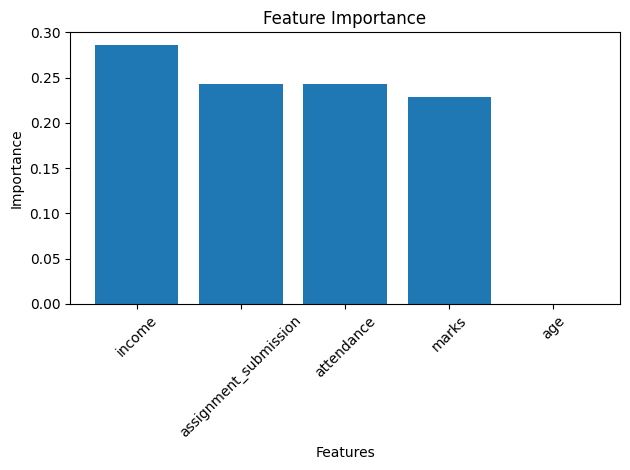

In [ ]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
}).sort_values(by="Importance", ascending=False)

plt.figure()
plt.bar(importance["Feature"], importance["Importance"])
plt.xticks(rotation=45)
plt.title("Feature Importance")
plt.xlabel("Features")
plt.ylabel("Importance")
plt.tight_layout()
plt.show()


### 9. Confusion Matrix Plot

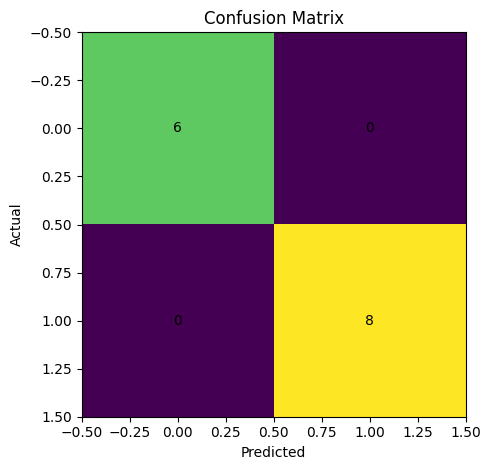

In [ ]:
cm = confusion_matrix(y_test, y_pred)

plt.figure()
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

# Annotate values
for i in range(len(cm)):
    for j in range(len(cm)):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.tight_layout()
plt.show()

### 10. Attendance vs Dropout Risk

/home/yash-rama/Desktop/EarlyDrop/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


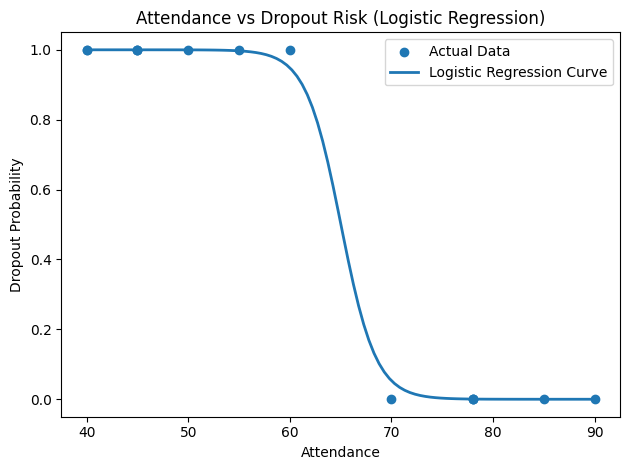

In [ ]:
# Use only attendance as feature
X_att = X_test[["attendance"]]

# Train logistic regression model
model = LogisticRegression()
model.fit(X_att, y_test)

# Create smooth values for curve
X_range = np.linspace(X_att.min(), X_att.max(), 100).reshape(-1, 1)

# Predict probabilities
y_prob = model.predict_proba(X_range)[:, 1]

# Plot
plt.figure()

# Scatter (actual data)
plt.scatter(X_att, y_test, label="Actual Data")

# Logistic curve
plt.plot(X_range, y_prob, linewidth=2, label="Logistic Regression Curve")

plt.xlabel("Attendance")
plt.ylabel("Dropout Probability")
plt.title("Attendance vs Dropout Risk (Logistic Regression)")
plt.legend()

plt.tight_layout()
plt.show()

### 11. Save Model

In [ ]:
joblib.dump(model, "dropout_model.pkl")

['dropout_model.pkl']